# Sarcasm Detection using RNN, LSTM, and Word2Vec Embeddings

## Final Portfolio Project – Language Classification Task

### Objective
The main objective of this project is to classify text into:
- **Sarcastic**
- **Not Sarcastic**

using Deep Learning models such as:
- Simple RNN
- LSTM
- LSTM with Pretrained Word2Vec Embeddings

---

## About the Dataset
The dataset used in this project is:
`sarcastic_headlines.csv`

The dataset contains:
- `headline` → News headline text
- `is_sarcastic` → Target label
    - `1 = Sarcastic`
    - `0 = Not Sarcastic`



## Project Workflow

The project follows these major steps:

1. Data Loading
2. Text Preprocessing
3. Exploratory Data Analysis
4. Tokenization and Padding
5. Building Deep Learning Models
6. Training and Evaluation
7. Error Analysis
8. Real-Time Prediction GUI



## Libraries and Frameworks Used

- Pandas
- NumPy
- Matplotlib
- Seaborn
- NLTK
- TensorFlow / Keras
- Scikit-learn
- Gensim



## Expected Outcome

At the end of this project, the models should be able to classify whether a given sentence or headline is sarcastic or not sarcastic with good accuracy.

In [1]:

!pip install contractions -q

print("Required library installed successfully.")

Required library installed successfully.


In [2]:

# Force Fix JAX / JAXLIB Conflict
!pip uninstall -y jax jaxlib
!pip install jax==0.7.2 jaxlib==0.7.2 -q



Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2


In [4]:
# Install Required Libraries


!pip install gensim -q

print("Libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.2 MB/s eta 0:00:00
Libraries installed successfully.


In [5]:

# Import Required Libraries


# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
import string

# NLTK Resources
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

# Word2Vec
import gensim.downloader as api

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Load Dataset

import pandas as pd

# Dataset path from Google Drive
file_path = "/content/drive/MyDrive/sarcastic_headlines.csv"

# Read dataset
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [8]:
# Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(28619, 2)

Column Names:
Index(['headline', 'is_sarcastic'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB

Missing Values:
headline        0
is_sarcastic    0
dtype: int64


In [9]:
# Display Random Samples from Dataset

print("Random Sarcastic Headlines:\n")

print(df[df['is_sarcastic'] == 1]['headline'].sample(5).values)

print("\n")

print("Random Non-Sarcastic Headlines:\n")

print(df[df['is_sarcastic'] == 0]['headline'].sample(5).values)

Random Sarcastic Headlines:

['historical archives: hy-genic apportionment of remaining paper'
 'floral arrangement at funeral talked about more than deceased'
 'state department warns americans traveling abroad to avoid lame amsterdam windmill tour'
 'woman all geared up to complain about work sidelined by friend with marital problems'
 'nonprofit places burnouts in jobs you can do blitzed out of your mind']


Random Non-Sarcastic Headlines:

['professor slammed to the ground by police, arrested for allegedly assaulting an officer'
 'breadwinner mommies:  are you falling short of your expectations? (or are your expectations falling short?)'
 'donald trump to skip naacp convention'
 "matt smith speaks out about 'the crown' pay gap"
 'cubans demand a direct and secret ballot to elect their president']


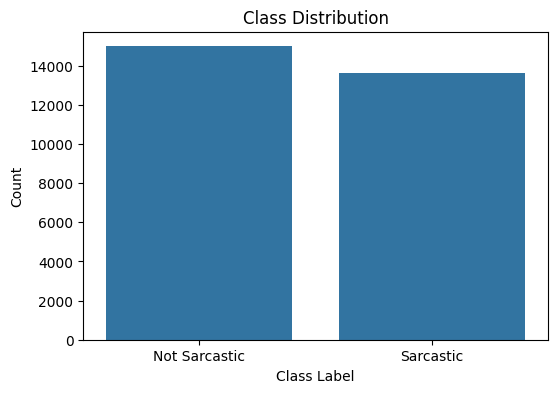

In [10]:
# Visualize Class Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='is_sarcastic', data=df)

plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.xticks([0, 1], ['Not Sarcastic', 'Sarcastic'])

plt.show()

# Text Preprocessing

In this section, the text data will be cleaned before feeding it into deep learning models.

The preprocessing steps include:

- Converting text to lowercase
- Removing URLs
- Removing punctuation and special characters
- Removing numbers
- Expanding contractions
- Removing stopwords
- Lemmatization

These preprocessing techniques help improve text quality and model performance.

In [11]:
# Download Additional NLTK Resources

nltk.download('omw-1.4')

print("Additional NLTK resources downloaded successfully.")

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Additional NLTK resources downloaded successfully.


In [12]:
# Import Contractions Library

import contractions

print("Contractions library imported successfully.")

Contractions library imported successfully.


In [13]:
# Download Required NLTK Resources

import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("NLTK resources downloaded successfully.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK resources downloaded successfully.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [14]:
# Initialize Stopwords and Lemmatizer

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

print("Stopwords and Lemmatizer initialized successfully.")

Stopwords and Lemmatizer initialized successfully.


In [15]:
# Text Cleaning Function

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into sentence
    text = ' '.join(cleaned_words)

    return text

In [16]:
# Download Punkt Tab Resource

nltk.download('punkt_tab')

print("Punkt tab downloaded successfully.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Punkt tab downloaded successfully.


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [17]:
# Apply Text Cleaning

df['cleaned_headline'] = df['headline'].apply(clean_text)

print("Text preprocessing completed successfully.")

Text preprocessing completed successfully.


In [18]:
# Display Original and Cleaned Text

for i in range(5):

    print("Original Text:")
    print(df['headline'][i])

    print("\nCleaned Text:")
    print(df['cleaned_headline'][i])

    print("\n")

Original Text:
thirtysomething scientists unveil doomsday clock of hair loss

Cleaned Text:
thirtysomething scientist unveil doomsday clock hair loss


Original Text:
dem rep. totally nails why congress is falling short on gender, racial equality

Cleaned Text:
dem rep totally nail congress falling short gender racial equality


Original Text:
eat your veggies: 9 deliciously different recipes

Cleaned Text:
eat veggie deliciously different recipe


Original Text:
inclement weather prevents liar from getting to work

Cleaned Text:
inclement weather prevents liar getting work


Original Text:
mother comes pretty close to using word 'streaming' correctly

Cleaned Text:
mother come pretty close using word streaming correctly




In [19]:
# Check Cleaned Dataset

df[['headline', 'cleaned_headline', 'is_sarcastic']].head()

,headline,cleaned_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1


In [20]:
# Check for Empty Cleaned Text

empty_text_count = (df['cleaned_headline'] == '').sum()

print("Number of Empty Cleaned Texts:")
print(empty_text_count)

Number of Empty Cleaned Texts:
2


In [21]:
# Check for Empty Cleaned Text

empty_text_count = (df['cleaned_headline'] == '').sum()

print("Number of Empty Cleaned Texts:")
print(empty_text_count)

Number of Empty Cleaned Texts:
2


# Text Preprocessing Completed

The text data has now been cleaned and prepared for deep learning models.

Completed preprocessing steps:
- Lowercasing
- URL removal
- Mention and hashtag removal
- Number removal
- Punctuation removal
- Contraction expansion
- Stopword removal
- Lemmatization

The next step is exploratory text analysis and visualization.

In [22]:
# Most Frequent Words Analysis

from collections import Counter

# Combine all cleaned text
all_words = ' '.join(df['cleaned_headline']).split()

# Count word frequency
word_freq = Counter(all_words)

# Get top 20 most common words
common_words = word_freq.most_common(20)

# Convert to DataFrame
freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

freq_df

,Word,Frequency
0,trump,1794
1,new,1677
2,man,1507
3,woman,884
4,say,709
5,report,690
6,get,637
7,day,589
8,one,579
9,year,558


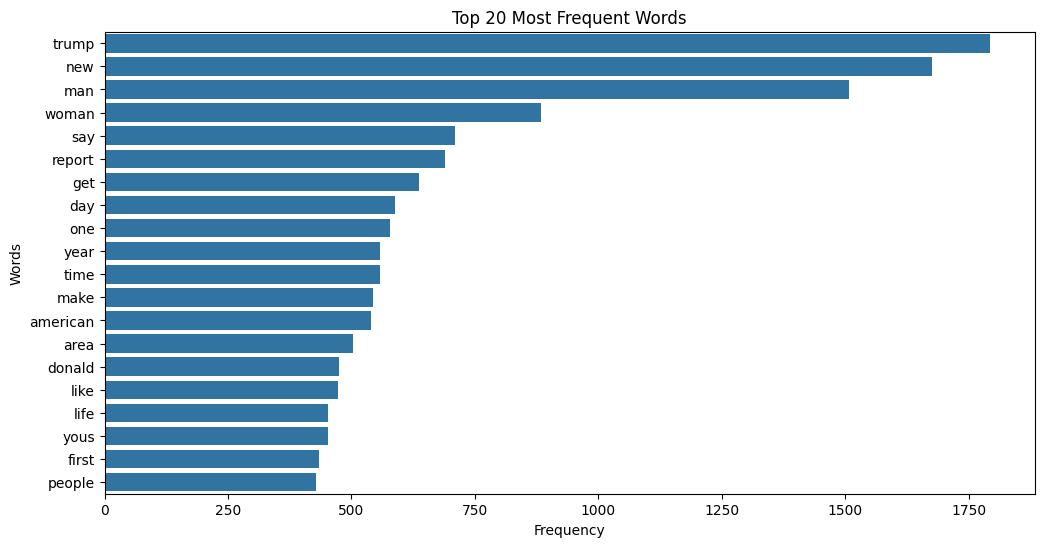

In [23]:
# Visualize Most Frequent Words

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=freq_df
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

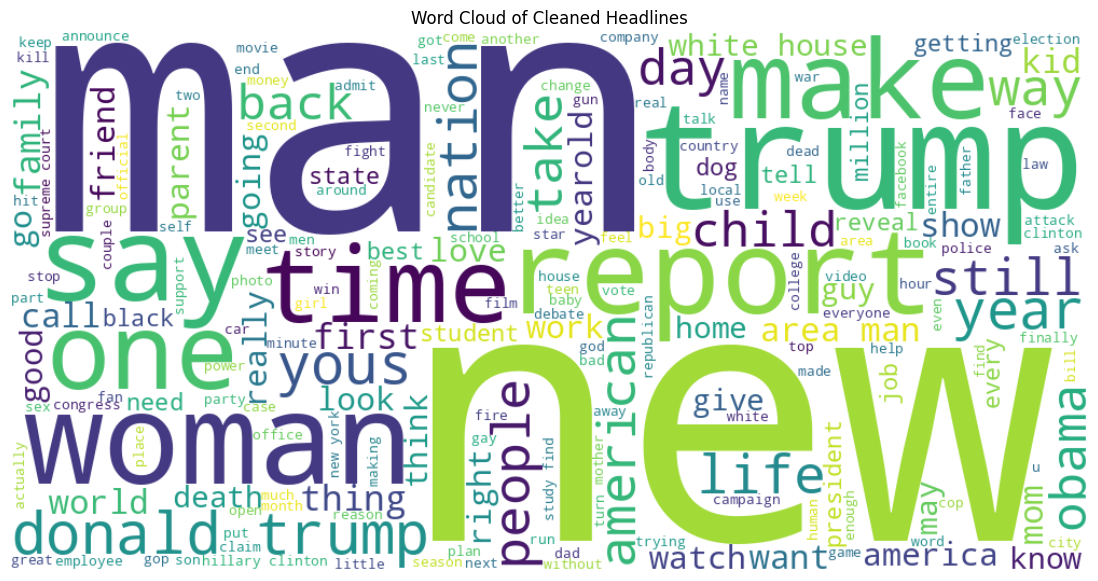

In [24]:
# Generate Word Cloud

from wordcloud import WordCloud

# Combine all cleaned text
text = ' '.join(df['cleaned_headline'])

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

# Display word cloud
plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Cleaned Headlines")

plt.show()

# Exploratory Text Analysis Completed

The exploratory analysis helps understand:
- Frequently occurring words
- Important text patterns
- Common vocabulary used in the dataset

The next step is tokenization and sequence padding for deep learning model preparation.

# Tokenization and Sequence Padding

Deep learning models cannot directly understand text data.

Therefore, the cleaned text must be converted into numerical sequences using tokenization.

After tokenization, sequence padding is applied so that all text sequences have equal length.

This helps the RNN and LSTM models process the input data efficiently.

In [25]:
# Define Features and Labels

X = df['cleaned_headline']

y = df['is_sarcastic']

print("Features and labels defined successfully.")

Features and labels defined successfully.


In [26]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (22895,)
Testing Data Shape: (5724,)


In [31]:
# Initialize Tokenizer

vocab_size = 20000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Tokenizer fitted successfully.")

Tokenizer fitted successfully.


In [32]:
# Convert Text to Sequences

X_train_sequences = tokenizer.texts_to_sequences(X_train)

X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Text converted into sequences successfully.")

Text converted into sequences successfully.


In [33]:
# Analyze Sequence Lengths

sequence_lengths = [len(sequence) for sequence in X_train_sequences]

print("Maximum Sequence Length:", max(sequence_lengths))

print("Average Sequence Length:", int(np.mean(sequence_lengths)))

Maximum Sequence Length: 106
Average Sequence Length: 7


In [34]:
# Calculate Percentile-Based Maximum Length

max_length = int(np.percentile(sequence_lengths, 95))

print("95th Percentile Sequence Length:", max_length)

95th Percentile Sequence Length: 11


In [35]:
# Apply Padding

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Padding completed successfully.")

Padding completed successfully.


In [36]:
# Create Validation Dataset

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Final Training Shape:", X_train_final.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test_padded.shape)

Final Training Shape: (20605, 11)
Validation Shape: (2290, 11)
Testing Shape: (5724, 11)


# Model Building

In this section, three deep learning models will be developed for sarcasm classification.

Models to be implemented:

1. Simple RNN with Trainable Embedding Layer
2. LSTM with Trainable Embedding Layer
3. LSTM with Pretrained Word2Vec Embeddings

The models will then be trained and evaluated to compare their performance.

In [37]:
# Define Common Parameters

embedding_dim = 128

print("Embedding Dimension:", embedding_dim)
print("Vocabulary Size:", vocab_size)
print("Maximum Sequence Length:", max_length)

Embedding Dimension: 128
Vocabulary Size: 20000
Maximum Sequence Length: 11


In [38]:
# Build Simple RNN Model

from tensorflow.keras.layers import Input

rnn_model = Sequential()

rnn_model.add(
    Input(shape=(max_length,))
)

rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
)

rnn_model.add(
    SimpleRNN(64)
)

rnn_model.add(
    Dropout(0.5)
)

rnn_model.add(
    Dense(1, activation='sigmoid')
)

print("Simple RNN model created successfully.")

Simple RNN model created successfully.


In [39]:
# Display RNN Model Summary

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,572,417 (9.81 MB)

 Trainable params: 2,572,417 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Compile Simple RNN Model

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Simple RNN model compiled successfully.")

Simple RNN model compiled successfully.


In [41]:
# Define Early Stopping Callback

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Early stopping callback created successfully.")

Early stopping callback created successfully.


In [42]:
# Train Simple RNN Model

history_rnn = rnn_model.fit(
    X_train_final,
    y_train_final,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7471 - loss: 0.5065 - val_accuracy: 0.8052 - val_loss: 0.4146
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9242 - loss: 0.1968 - val_accuracy: 0.7659 - val_loss: 0.5069
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9772 - loss: 0.0693 - val_accuracy: 0.7996 - val_loss: 0.6402
Epoch 4/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9896 - loss: 0.0329 - val_accuracy: 0.7913 - val_loss: 0.7985


In [43]:
# Evaluate Simple RNN Model on Test Data

rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_padded, y_test)

print("Simple RNN Test Loss:", rnn_loss)
print("Simple RNN Test Accuracy:", rnn_accuracy)

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7961 - loss: 0.4336
Simple RNN Test Loss: 0.43361788988113403
Simple RNN Test Accuracy: 0.7961215972900391


In [44]:
# Predict Using Simple RNN Model

rnn_predictions = rnn_model.predict(X_test_padded)

rnn_predictions = (rnn_predictions > 0.5).astype("int32")

print("Prediction completed successfully.")

179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediction completed successfully.


In [45]:
# Classification Report for Simple RNN

print("Simple RNN Classification Report:")
print(classification_report(y_test, rnn_predictions))

Simple RNN Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.80      2997
           1       0.76      0.83      0.80      2727

    accuracy                           0.80      5724
   macro avg       0.80      0.80      0.80      5724
weighted avg       0.80      0.80      0.80      5724



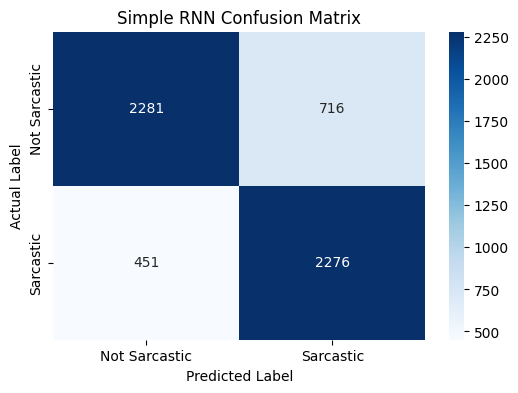

In [46]:
# Confusion Matrix for Simple RNN

rnn_cm = confusion_matrix(y_test, rnn_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

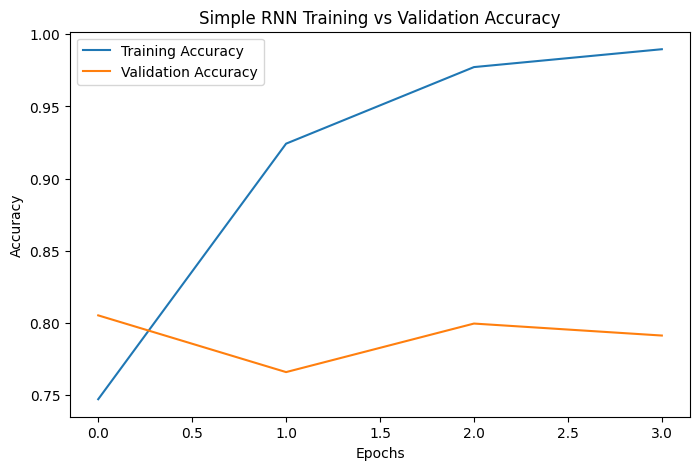

In [47]:
# Plot Simple RNN Training History

plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("Simple RNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

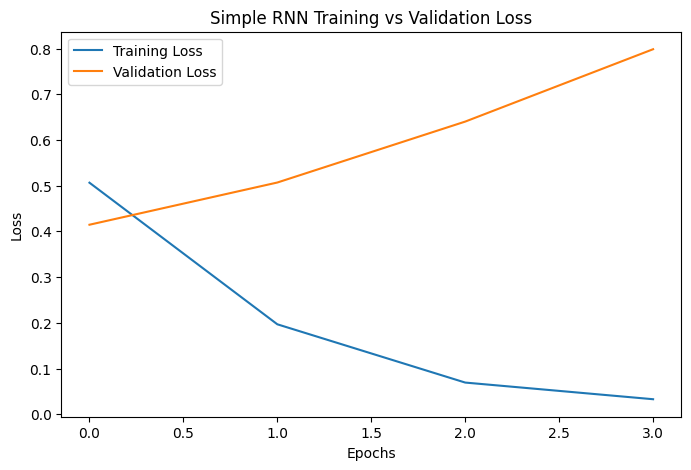

In [48]:
# Plot Simple RNN Loss History

plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("Simple RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Simple RNN Model Observation

The Simple RNN model achieved reasonable performance for sarcasm classification.

However, the validation loss increased after the first epoch while training accuracy continued to improve. This indicates that the model started overfitting early.

The Simple RNN model will be compared with LSTM and LSTM with pretrained Word2Vec embeddings in the next sections.

# LSTM Model with Trainable Embedding Layer

In this section, an LSTM model will be built for sarcasm classification.

LSTM is more powerful than Simple RNN because it can remember long-term patterns in sequential text data and helps reduce the vanishing gradient problem.

In [49]:
# Build LSTM Model

lstm_model = Sequential()

lstm_model.add(
    Input(shape=(max_length,))
)

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
)

lstm_model.add(
    LSTM(64)
)

lstm_model.add(
    Dropout(0.5)
)

lstm_model.add(
    Dense(1, activation='sigmoid')
)

print("LSTM model created successfully.")

LSTM model created successfully.


In [50]:
# Display LSTM Model Summary

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Compile LSTM Model

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("LSTM model compiled successfully.")

LSTM model compiled successfully.


In [52]:
# Train LSTM Model

history_lstm = lstm_model.fit(
    X_train_final,
    y_train_final,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7506 - loss: 0.4976 - val_accuracy: 0.8013 - val_loss: 0.4252
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8880 - loss: 0.2741 - val_accuracy: 0.8197 - val_loss: 0.4069
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9399 - loss: 0.1566 - val_accuracy: 0.8122 - val_loss: 0.5926
Epoch 4/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9686 - loss: 0.0872 - val_accuracy: 0.8087 - val_loss: 0.7110
Epoch 5/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9803 - loss: 0.0513 - val_accuracy: 0.8048 - val_loss: 0.8287


In [53]:
# Evaluate LSTM Model on Test Data

lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_padded, y_test)

print("LSTM Test Loss:", lstm_loss)
print("LSTM Test Accuracy:", lstm_accuracy)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7940 - loss: 0.4622
LSTM Test Loss: 0.46220481395721436
LSTM Test Accuracy: 0.794025182723999


In [54]:
# Predict Using LSTM Model

lstm_predictions = lstm_model.predict(X_test_padded)

lstm_predictions = (lstm_predictions > 0.5).astype("int32")

print("Prediction completed successfully.")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction completed successfully.


In [55]:
# Classification Report for LSTM

print("LSTM Classification Report:")
print(classification_report(y_test, lstm_predictions))

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81      2997
           1       0.79      0.77      0.78      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724



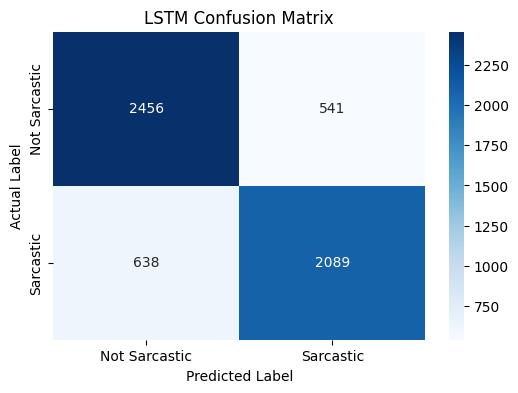

In [56]:
# Confusion Matrix for LSTM

lstm_cm = confusion_matrix(y_test, lstm_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

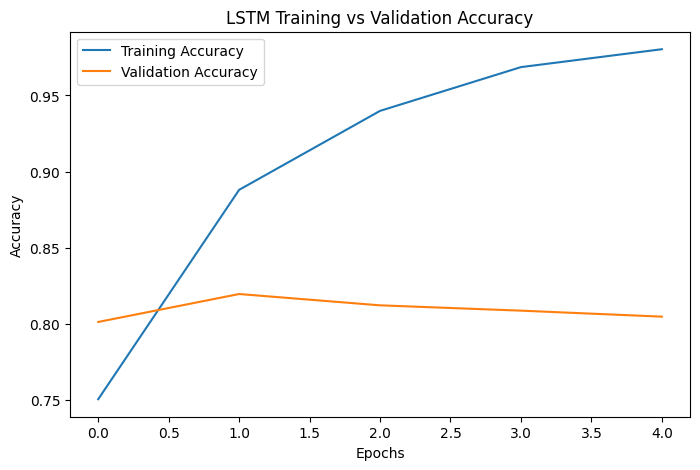

In [57]:
# Plot LSTM Training History

plt.figure(figsize=(8, 5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

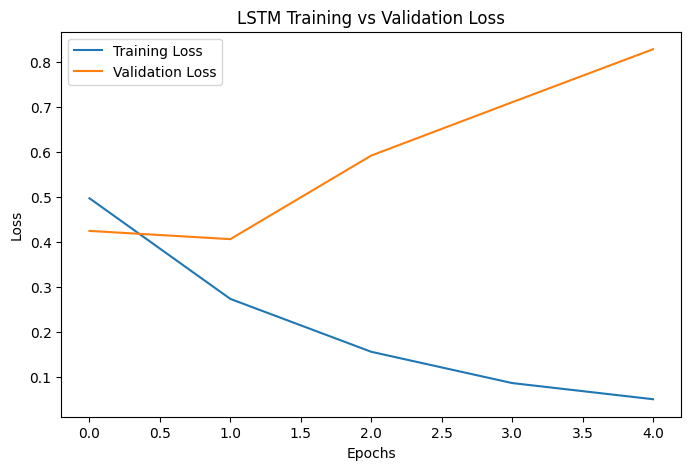

In [58]:
# Plot LSTM Loss History

plt.figure(figsize=(8, 5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [59]:
# Function for Real Prediction

def predict_sarcasm(model, text):

    # Clean text
    cleaned_text = clean_text(text)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_text])

    # Apply padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # Predict
    prediction = model.predict(padded_sequence)[0][0]

    # Convert probability into label
    if prediction >= 0.5:
        label = "Sarcastic"
    else:
        label = "Not Sarcastic"

    print("Input Text:")
    print(text)

    print("\nPredicted Label:")
    print(label)

    print("\nPrediction Probability:")
    print(round(float(prediction), 4))

In [60]:
# Test Sample 1

sample_text_1 = "Oh great, another Monday morning meeting."

predict_sarcasm(lstm_model, sample_text_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Input Text:
Oh great, another Monday morning meeting.

Predicted Label:
Not Sarcastic

Prediction Probability:
0.2235


In [61]:
# Test Sample 2

sample_text_2 = "The weather is very pleasant today."

predict_sarcasm(lstm_model, sample_text_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Input Text:
The weather is very pleasant today.

Predicted Label:
Not Sarcastic

Prediction Probability:
0.1644


In [62]:
# Test Sample 3

sample_text_3 = "I absolutely love waiting in traffic for hours."

predict_sarcasm(lstm_model, sample_text_3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Input Text:
I absolutely love waiting in traffic for hours.

Predicted Label:
Sarcastic

Prediction Probability:
0.8139


In [64]:
# Load Pretrained Word2Vec Embeddings

import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-300')

print("Pretrained Word2Vec embeddings loaded successfully.")

[==================================================] 100.0% 376.1/376.1MB downloaded
Pretrained Word2Vec embeddings loaded successfully.


In [65]:
# Create Embedding Matrix

embedding_dim_w2v = 300

word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

for word, i in word_index.items():

    if i < vocab_size:

        if word in embedding_model:

            embedding_vector = embedding_model[word]

            embedding_matrix[i] = embedding_vector

print("Embedding matrix created successfully.")

Embedding matrix created successfully.


In [66]:
# Build LSTM Model with Pretrained Word2Vec Embeddings

w2v_lstm_model = Sequential()

w2v_lstm_model.add(
    Input(shape=(max_length,))
)

w2v_lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False
    )
)

w2v_lstm_model.add(
    LSTM(64)
)

w2v_lstm_model.add(
    Dropout(0.5)
)

w2v_lstm_model.add(
    Dense(1, activation='sigmoid')
)

print("Word2Vec LSTM model created successfully.")

Word2Vec LSTM model created successfully.


In [67]:
# Display Word2Vec LSTM Model Summary

w2v_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 300)        │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,093,505 (23.24 MB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

In [68]:
# Compile Word2Vec LSTM Model

w2v_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Word2Vec LSTM model compiled successfully.")

Word2Vec LSTM model compiled successfully.


In [70]:
# Define Early Stopping for Word2Vec LSTM

early_stopping_w2v = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

print("Word2Vec EarlyStopping callback created successfully.")

Word2Vec EarlyStopping callback created successfully.


In [71]:
# Train Word2Vec LSTM Model

history_w2v_lstm = w2v_lstm_model.fit(
    X_train_final,
    y_train_final,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8043 - loss: 0.4245 - val_accuracy: 0.8092 - val_loss: 0.4175
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8387 - loss: 0.3673 - val_accuracy: 0.8148 - val_loss: 0.3972
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8652 - loss: 0.3112 - val_accuracy: 0.8079 - val_loss: 0.4305
Epoch 4/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8948 - loss: 0.2542 - val_accuracy: 0.8153 - val_loss: 0.4318
Epoch 5/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9199 - loss: 0.2032 - val_accuracy: 0.8301 - val_loss: 0.4448


In [72]:
# Evaluate Word2Vec LSTM Model on Test Data

w2v_lstm_loss, w2v_lstm_accuracy = w2v_lstm_model.evaluate(X_test_padded, y_test)

print("Word2Vec LSTM Test Loss:", w2v_lstm_loss)
print("Word2Vec LSTM Test Accuracy:", w2v_lstm_accuracy)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8094 - loss: 0.4162
Word2Vec LSTM Test Loss: 0.4161624014377594
Word2Vec LSTM Test Accuracy: 0.8093990087509155


In [73]:
# Predict Using Word2Vec LSTM Model

w2v_lstm_predictions = w2v_lstm_model.predict(X_test_padded)

w2v_lstm_predictions = (w2v_lstm_predictions > 0.5).astype("int32")

print("Prediction completed successfully.")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Prediction completed successfully.


In [75]:
# Classification Report for Word2Vec LSTM

print("Word2Vec LSTM Classification Report:")
print(classification_report(y_test, w2v_lstm_predictions))

Word2Vec LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      2997
           1       0.84      0.74      0.79      2727

    accuracy                           0.81      5724
   macro avg       0.81      0.81      0.81      5724
weighted avg       0.81      0.81      0.81      5724



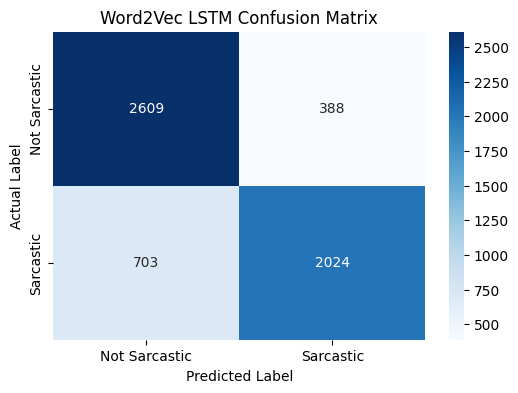

In [76]:
# Confusion Matrix for Word2Vec LSTM

w2v_lstm_cm = confusion_matrix(y_test, w2v_lstm_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    w2v_lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("Word2Vec LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

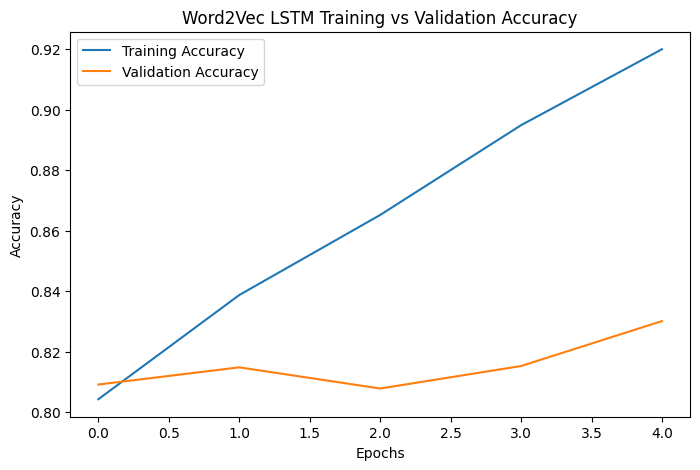

In [77]:
# Plot Word2Vec LSTM Training History

plt.figure(figsize=(8, 5))

plt.plot(history_w2v_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_w2v_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("Word2Vec LSTM Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

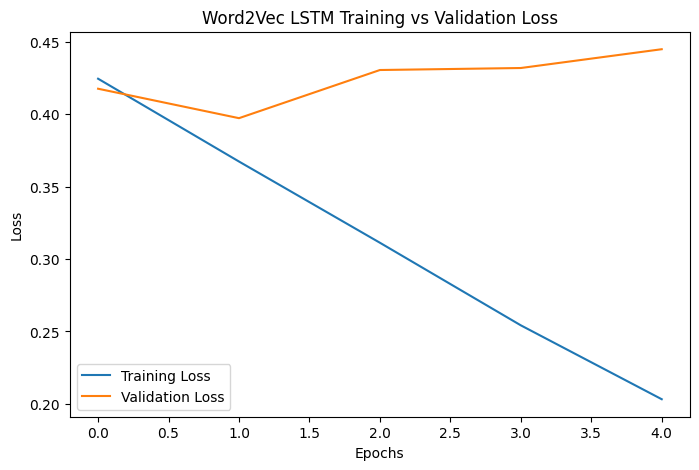

In [78]:
# Plot Word2Vec LSTM Loss History

plt.figure(figsize=(8, 5))

plt.plot(history_w2v_lstm.history['loss'], label='Training Loss')
plt.plot(history_w2v_lstm.history['val_loss'], label='Validation Loss')

plt.title("Word2Vec LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Model Performance Comparison

In this section, the performances of all three models are compared.

Models Compared:
- Simple RNN
- LSTM
- LSTM with Pretrained Word2Vec Embeddings

The comparison helps identify which model performs best for sarcasm classification.

In [79]:
# Create Model Comparison Table

comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'Word2Vec LSTM'
    ],
    'Test Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        w2v_lstm_accuracy
    ],
    'Test Loss': [
        rnn_loss,
        lstm_loss,
        w2v_lstm_loss
    ]
})

comparison_df

,Model,Test Accuracy,Test Loss
0,Simple RNN,0.796122,0.433618
1,LSTM,0.794025,0.462205
2,Word2Vec LSTM,0.809399,0.416162


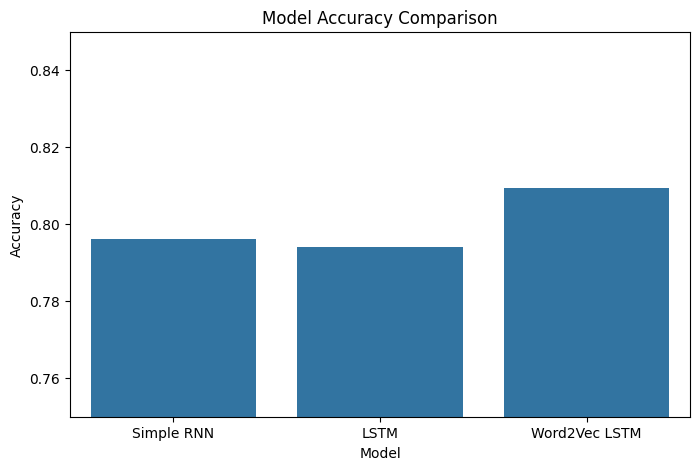

In [80]:
# Visualize Model Accuracy Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Model',
    y='Test Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.75, 0.85)

plt.show()

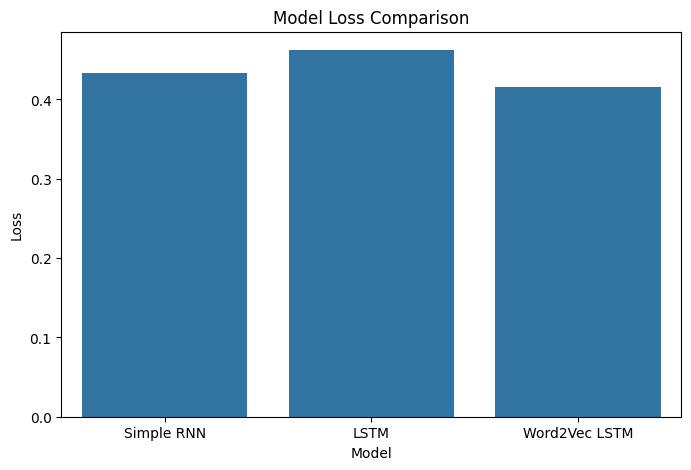

In [81]:
# Visualize Model Loss Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Model',
    y='Test Loss',
    data=comparison_df
)

plt.title("Model Loss Comparison")
plt.ylabel("Loss")

plt.show()

# Model Comparison Observation

Among the three models, the LSTM model with pretrained Word2Vec embeddings achieved the highest test accuracy.

Observations:
- Simple RNN performed reasonably well but showed early overfitting.
- Standard LSTM slightly improved sequence learning capability.
- Word2Vec LSTM achieved the best performance because pretrained embeddings provided richer semantic understanding of words.

The results indicate that pretrained embeddings improve sarcasm classification performance by capturing contextual relationships between words more effectively.

# Error Analysis

Error analysis helps understand the weaknesses and limitations of the model.

In this section:
- Misclassified examples will be analyzed
- Possible reasons for incorrect predictions will be discussed
- Potential improvements will be suggested

In [82]:
# Create DataFrame for Error Analysis

error_analysis_df = pd.DataFrame({
    'Text': X_test.values,
    'Actual Label': y_test.values,
    'Predicted Label': w2v_lstm_predictions.flatten()
})

# Filter Incorrect Predictions
misclassified_df = error_analysis_df[
    error_analysis_df['Actual Label'] != error_analysis_df['Predicted Label']
]

print("Number of Misclassified Samples:")
print(len(misclassified_df))

Number of Misclassified Samples:
1091


In [83]:
# Display Misclassified Examples

misclassified_df.head(10)

,Text,Actual Label,Predicted Label
4,democratic congressman protest trump environme...,1,0
5,rex tillerson call report ouster laughable,0,1
8,neighbor bragging pound box fedexed,1,0
11,prayer answered random series event cold uncar...,1,0
14,tom gilbert actor portrays tv regis philbin le...,1,0
18,huckabee back denying abortion yearold raped s...,0,1
20,kate middleton suffering morning sickness,1,0
21,metta world peace think matt barnes fight fact...,0,1
34,mother day card mailed,1,0
38,kung fu master iron crotch one ballsy martial ...,0,1


In [84]:
# Display Random Misclassified Examples

misclassified_samples = misclassified_df.sample(5)

misclassified_samples

,Text,Actual Label,Predicted Label
139,john kerry lost somewhere gobi desert,1,0
1437,pelosi throw cold water tax extenders bill tal...,0,1
5594,well known gresham musician form gresham super...,1,0
1606,firm help small community remove contamination...,0,1
1732,either ming yuan dynasty seizes control mainla...,1,0


# Error Analysis Observation

Some headlines were misclassified because sarcasm is highly dependent on:
- Context
- Tone
- Human understanding
- Hidden meaning

Possible reasons for errors:
- Subtle sarcasm without obvious sarcastic words
- Ambiguous sentence structures
- Limited contextual understanding
- Short text sequences

Examples such as:
"oh great another monday meeting"
may appear positive in wording but actually express sarcasm.

Potential Improvements:
- Larger dataset
- Bidirectional LSTM
- Transformer-based models such as BERT
- Fine-tuning pretrained embeddings
- Attention mechanisms

In [86]:
# Save Best Model

w2v_lstm_model.save("best_sarcasm_model.h5")

print("Best model saved successfully.")

Best model saved successfully.


In [87]:
# Save Tokenizer

import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [88]:
# Save Maximum Sequence Length

with open("max_length.pkl", "wb") as file:
    pickle.dump(max_length, file)

print("Maximum sequence length saved successfully.")

Maximum sequence length saved successfully.


In [89]:
# Test Best Model on Custom Inputs

custom_samples = [
    "I absolutely enjoy getting stuck in traffic every day.",
    "The food was delicious and everyone enjoyed the event.",
    "Oh wonderful, my phone battery died again.",
    "The meeting was conducted successfully today."
]

for text in custom_samples:

    predict_sarcasm(w2v_lstm_model, text)

    print("\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Input Text:
I absolutely enjoy getting stuck in traffic every day.

Predicted Label:
Sarcastic

Prediction Probability:
0.9658


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Input Text:
The food was delicious and everyone enjoyed the event.

Predicted Label:
Not Sarcastic

Prediction Probability:
0.0571


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Input Text:
Oh wonderful, my phone battery died again.

Predicted Label:
Not Sarcastic

Prediction Probability:
0.2385


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Input Text:
The meeting was conducted successfully today.

Predicted Label:
Not Sarcastic

Prediction Probability:
0.2359




In [90]:
# Create Folder Path in Google Drive

save_path = "/content/drive/MyDrive/Sarcasm_Project/"

print("Save path created.")

Save path created.


In [91]:
# Save Best Model to Google Drive

w2v_lstm_model.save(save_path + "best_sarcasm_model.h5")

print("Best model saved to Google Drive successfully.")

Best model saved to Google Drive successfully.


In [92]:
# Save Tokenizer to Google Drive

with open(save_path + "tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [93]:
# Save Maximum Sequence Length to Google Drive

with open(save_path + "max_length.pkl", "wb") as file:
    pickle.dump(max_length, file)

print("Maximum sequence length saved successfully.")

Maximum sequence length saved successfully.


In [94]:
# Save Training Histories

with open(save_path + "history_rnn.pkl", "wb") as file:
    pickle.dump(history_rnn.history, file)

with open(save_path + "history_lstm.pkl", "wb") as file:
    pickle.dump(history_lstm.history, file)

with open(save_path + "history_w2v_lstm.pkl", "wb") as file:
    pickle.dump(history_w2v_lstm.history, file)

print("Training histories saved successfully.")

Training histories saved successfully.
